In [1]:
import torch

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../scripts')
from functions import *

import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import copy
import wandb

In [3]:
## load data

df_sim = pd.read_hdf('../simulated-streams/simulated_patch.h5')
df_sim.columns = ["pmdec", "pmra", "dec", "ra", "b-r", "g", 
                "rotra", "rotdec", "rotpmra", "rotpmdec", "stream", "ra_wrapped"]
df_sim.head()

,pmdec,pmra,dec,ra,b-r,g,rotra,rotdec,rotpmra,rotpmdec,stream,ra_wrapped
0,-11.000000,-4.833510,56.719927,172.465520,0.966099,18.886600,8.841160,0.281291,-2.098208,-11.830484,False,172.465520
1,2.533410,-26.788700,56.716618,172.410941,1.419800,17.494600,8.812834,0.271012,-26.632043,-3.845377,False,172.410941
2,-0.442341,-0.380034,56.719300,172.385308,1.229799,17.822701,8.798531,0.270310,-0.265391,-0.519287,False,172.385308
3,-16.743200,0.573184,56.719773,172.364918,0.819900,14.634200,8.787544,0.268140,4.488552,-16.140514,False,172.364918
4,-7.191590,-1.666070,56.701709,172.323133,0.758999,18.575701,8.769486,0.245202,0.064643,-7.381773,False,172.323133


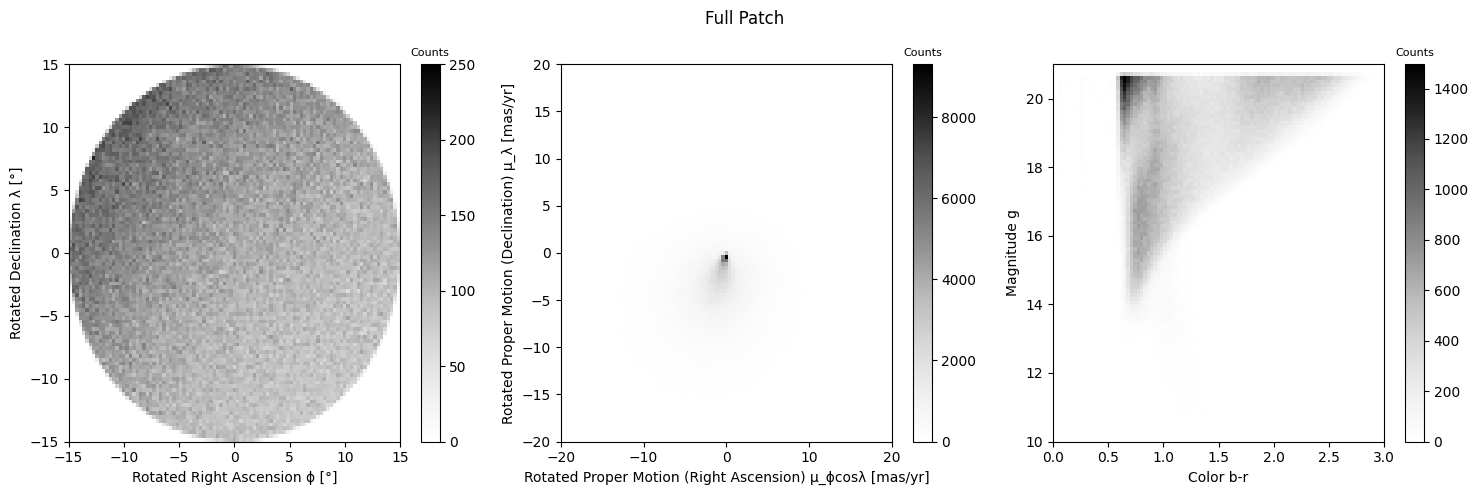

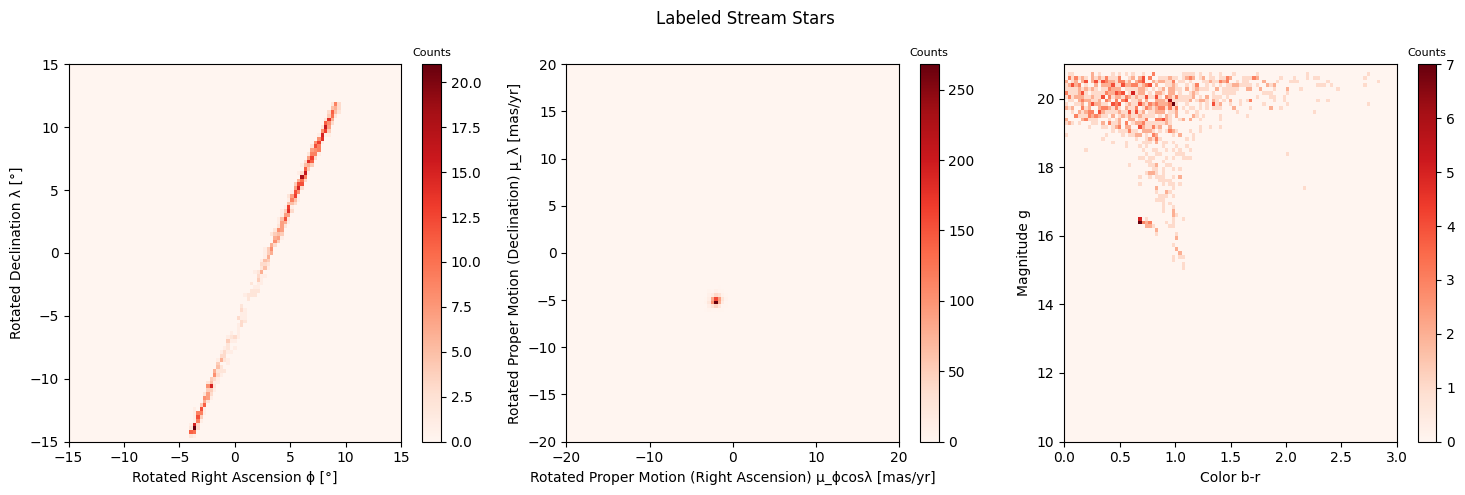

In [4]:
## plot data
plot_data(df_sim)

Signal parameter: Rotated and Centered Proper Motion (DEC) μ_λ
Signal region factor = 0.25 and sideband region factor = 0.5
Signal parameter median = -5.094
Signal parameter standard deviation = 5.001
Signal Region Range: [-6.344, -3.844]
Sideband Region Range: [-7.594, -6.344) and (-3.844, -2.593]
Signal Region has 175716 stars, 1124 stream and 174592 background.
Sideband Region has 171334 stars, 3 stream and 171331 background.
Outer Region has 539627 stars, 34 stream and 539593 background.


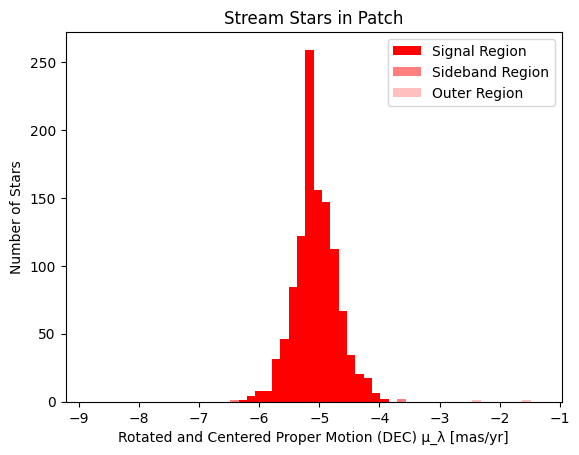

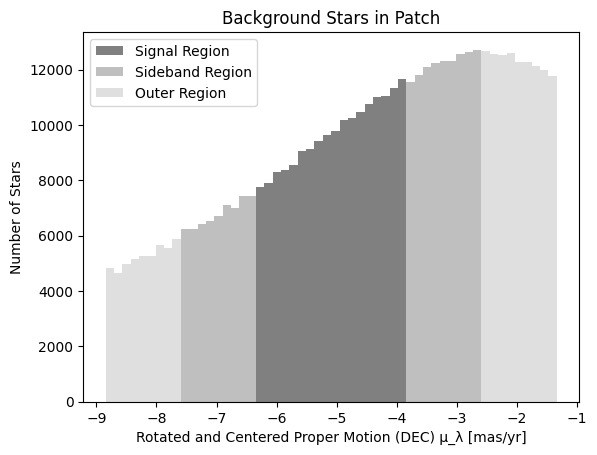

In [5]:
# region labels and plots
df_regions = signal_sideband(df_sim)

In [4]:

def cwola_train(df, pm_parameter='rotpmdec', dropout=0.2, k_folds=5, batch_size=10000, lr=0.001, patience=30, epochs=100, trainval_loops=3, save_folder='results/simulated-1full', wandbproj='simulated-1full'):

    os.makedirs(save_folder, exist_ok=True)

    # training variables
    if pm_parameter == 'rotpmdec':
        training_vars = ['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']
    if pm_parameter == 'rotpmra':
        training_vars = ['b-r', 'g', 'rotra', 'rotdec', 'rotpmdec']

    # model architecture
    class NeuralNetwork(nn.Module):
        def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1, dropout=dropout): # create tool, parameters for recalling, call function is used after
            super().__init__() # access all methods, attributes, etc of class
            self.NeuralNetwork = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=dropout),       
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=dropout),       
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=dropout),       
                nn.Linear(hidden_dim, output_dim),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.NeuralNetwork(x)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    # k-folding
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=18)

    fold_stars = [] # will be a list of k (5) arrays, representing the k folds
    for fold_idx, (train_index, test_index) in enumerate(skf.split(df[training_vars], df['region_label'])):
        fold_stars.append(test_index)
    fold_labels = np.arange(len(fold_stars)) # fold labels is an array of values 0-4, representing indices/labels of the 5 folds
    
    for test_idx in fold_labels:
        test_stars = fold_stars[test_idx]
        save_folder_test = os.path.join(save_folder, "test_fold_{}".format(test_idx))
        os.makedirs(save_folder_test, exist_ok=True)

        # cycles through remaining sets (minus the test set) for validation sets
        for val_idx in np.delete(fold_labels, test_idx):
            val_stars = fold_stars[val_idx]
    
            train_indices = np.delete(fold_labels, [test_idx, val_idx])
            train_stars = np.concatenate([fold_stars[train_idx] for train_idx in train_indices])
    
            # create data frames with indices
            df_train = df.iloc[train_stars]
            df_val = df.iloc[val_stars]
            df_test = df.iloc[test_stars]
    
            train_x = df_train[training_vars]
            train_y = df_train['region_label'].to_numpy()
    
            val_x = df_val[training_vars]
            val_y = df_val['region_label'].to_numpy()
    
            test_x = df_test[training_vars]
            test_y = df_test['region_label'].to_numpy()
            test_y_true = df_test['stream'].to_numpy(dtype=int)

            # scale data
            scaler = StandardScaler()
            
            train_x = scaler.fit_transform(train_x) # fit_transform called only on train data
            val_x = scaler.transform(val_x)
            test_x = scaler.transform(test_x)
                    

            ## create tensors, datasets, and loaders
            train_x_tensor = torch.tensor(np.array(train_x))
            train_y_tensor = torch.tensor(train_y)
                
            val_x_tensor = torch.tensor(np.array(val_x))
            val_y_tensor = torch.tensor(val_y)
                
            test_x_tensor = torch.tensor(np.array(test_x))
            test_y_tensor = torch.tensor(test_y)
            test_y_true_tensor = torch.tensor(test_y_true)
                
            train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
            val_dataset = TensorDataset(val_x_tensor, val_y_tensor)
            test_dataset = TensorDataset(test_x_tensor, test_y_tensor, test_y_true_tensor)
                
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
            test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

            best_loop_val_loss = float('inf')

            test_nn_scores = []
            
            for n in range(trainval_loops):

                # initialize model
                run = wandb.init(project=wandbproj, 
                            group=f"fold_{test_idx}", 
                            job_type=f"val_set_{val_idx}", 
                            name=f"val_{val_idx}_train_{n}",
                            config={"test_fold": test_idx, "val_set": val_idx, "train_loop": n},
                            reinit=True)
                model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1, dropout=dropout).to(device)
                loss_fn = nn.BCELoss()
                optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
                best_val_loss = float('inf')
                patience_counter = 0
                
                for epoch in range(epochs):
                
                    # training
                    model.train()
                    total_train_loss = 0
                    train_correct, counts = 0, 0
                    for inputs, region_labels in train_loader:
                        optimizer.zero_grad()
                        inputs = inputs.to(device).float()
                        region_labels = region_labels.to(device).float()
                        
                        out = model(inputs).squeeze(1)
                        loss = loss_fn(out, region_labels)
                        loss.backward()
                        optimizer.step()
                        total_train_loss += loss.item()
                
                        predictions = (out > 0.5).float()
                        train_correct += (predictions == region_labels).sum().item()
                        counts += region_labels.size(0)
                
                    avg_train_loss = total_train_loss / len(train_loader)
                    train_accuracy = train_correct / counts
                
                    # validation
                    model.eval()
                    total_val_loss = 0
                    val_correct, counts = 0.0, 0
                    for inputs, region_labels in val_loader:
                        inputs = inputs.to(device).float()
                        region_labels = region_labels.to(device).float()
                
                        out = model(inputs).squeeze(1)  # forward pass
                        loss = loss_fn(out, region_labels)  # compute loss
                        total_val_loss += loss.item()
                
                        predictions = (out > 0.5).float()
                        val_correct += (predictions == region_labels).sum().item()
                        counts += region_labels.size(0)
                
                    avg_val_loss = total_val_loss / len(val_loader)
                    val_accuracy = val_correct / counts

                    wandb.log({"train_loss": avg_train_loss, "val_loss": avg_val_loss, 
                             "train_acc": train_accuracy, "val_acc": val_accuracy, "epoch": epoch})
                    
                    # early stopping
                    if avg_val_loss < best_val_loss:
                        best_val_loss = avg_val_loss
                        patience_counter = 0
                        best_model = copy.deepcopy(model.state_dict())
                    else:
                        patience_counter += 1
                
                    if patience_counter >= patience:
                        print("Early stopping")
                        break
                
                if best_val_loss < best_loop_val_loss:
                    best_loop_val_loss = best_val_loss
                    lowest_val_loss_model = best_model ## model parameters from epoch with the lowest validation loss

                run.finish()

            model_save_path = os.path.join(save_folder_test, "val_set_{}_best_model".format(val_idx))
            torch.save(lowest_val_loss_model, model_save_path) ## model parameters from training run with the lowest validation loss

            model.load_state_dict(lowest_val_loss_model)

            model.eval()
            test_loss, test_correct, counts = 0.0, 0.0, 0
            all_scores = []
            all_region_labels = []
            all_true_labels = []
            raw_scores = []
            
            with torch.no_grad():
                for inputs, region_labels, true_labels in test_loader:
                    
                    inputs = inputs.to(device).float()
                    region_labels = region_labels.to(device).float()
                    out = model(inputs).squeeze()
                    raw_scores.extend(out.squeeze().cpu().numpy())
                    loss = loss_fn(out, region_labels)
                    test_loss += loss.item() * inputs.size(0)
            
                    scores = (out > 0.5).float()
                    all_scores.extend(scores.squeeze().cpu().numpy())
                    
                    all_region_labels.extend(region_labels.squeeze().cpu().numpy())
                    all_true_labels.extend(true_labels.numpy())
                        
                    # Track counts
                    test_correct += (scores == region_labels).sum().item()
                    counts += region_labels.size(0)
            
            all_scores = np.array(all_scores)
            all_region_labels = np.array(all_region_labels)
            all_true_labels = np.array(all_true_labels)
            raw_scores = np.array(raw_scores)

            test_nn_scores.append(raw_scores)
    
        df_test['nn_score'] = np.mean(test_nn_scores, axis=0)

        ### plot, metrics, etc!

        
        
    return df_test_full

In [5]:
### what metrics, what fiducial cuts, etc.???? **** first from paper
            
            # print(' ')
            # print('----------------------------------------')
            # print(' ')
            
            
            # plt.hist(raw_scores)
            # plt.title('Raw NN Scores')
            
            # # calculate ROC-AUC score
            # auc_regions = roc_auc_score(all_region_labels, raw_scores)
            # print(' ')
            # print(f"Test ROC-AUC for fully supervised signal/sb region classifier: {auc_regions:.4f}")
            
            # auc_true = roc_auc_score(all_true_labels, raw_scores)
            # print(f"Test ROC-AUC for true background/stream labels: {auc_true:.4f}")
            
            # # calculate purity and completeness
            
            # true_pos = np.sum((all_scores == 1) & (all_true_labels == 1))
            # false_pos = np.sum((all_scores == 1) & (all_true_labels == 0))
            # true_neg = np.sum((all_scores == 0) & (all_true_labels == 0))
            # false_neg = np.sum((all_scores == 0) & (all_true_labels == 1))
            
            # purity = true_pos / (true_pos + false_pos)
            # completeness = true_pos / (true_pos + false_neg)
            # print(' ')
            # print(f'Purity = {purity}')
            # print(f'Completeness = {completeness}')